In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import read_dataset, PCA

plt.rcParams.update({'font.size': 20})
sns.set_style("darkgrid")

# EDA & Data Preprocessing
In this notebook, we're going to carry out a few EDA operations to get acquainted with the data set of the challenge. We will analyze the 7 features and their relationships, generate new derived features and justify the representativeness of a 10% subsample on the basis of faster subsequent training.

In [2]:
# 1s
df_x, df_y = read_dataset('original')
df = pd.concat([df_x, df_y], axis=1)
df_normalized = read_dataset('original',normalization='normalize', merge=True)
df_standardized = read_dataset('original',normalization='standardize', merge=True)
df.describe(percentiles=[0.5])

,trq_measured,oat,mgt,pa,ias,np,ng,faulty,trq_margin,trq_target
count,742625.000000,742625.000000,742625.000000,742625.000000,742625.000000,742625.000000,742625.000000,742625.000000,742625.000000,742625.000000
mean,65.097549,12.675167,592.246116,511.776065,79.324591,97.377919,95.517281,0.403189,-1.157346,66.711490
std,13.253672,8.066084,39.654582,563.190555,35.395075,3.996721,3.635084,0.490538,14.068843,14.170206
min,14.673340,-19.250000,467.300000,-208.389200,0.000000,85.010000,90.001830,0.000000,-74.747111,22.454554
50%,65.700000,13.703440,589.400000,340.461600,88.375000,99.759770,94.810000,0.000000,1.693847,66.001495
max,104.730500,36.799130,723.400000,3097.510000,137.562500,101.560000,101.220000,1.000000,34.148857,114.608196


### Skewness study
Here we plot the distribution of each feature, with particular concern towards its skewness value.

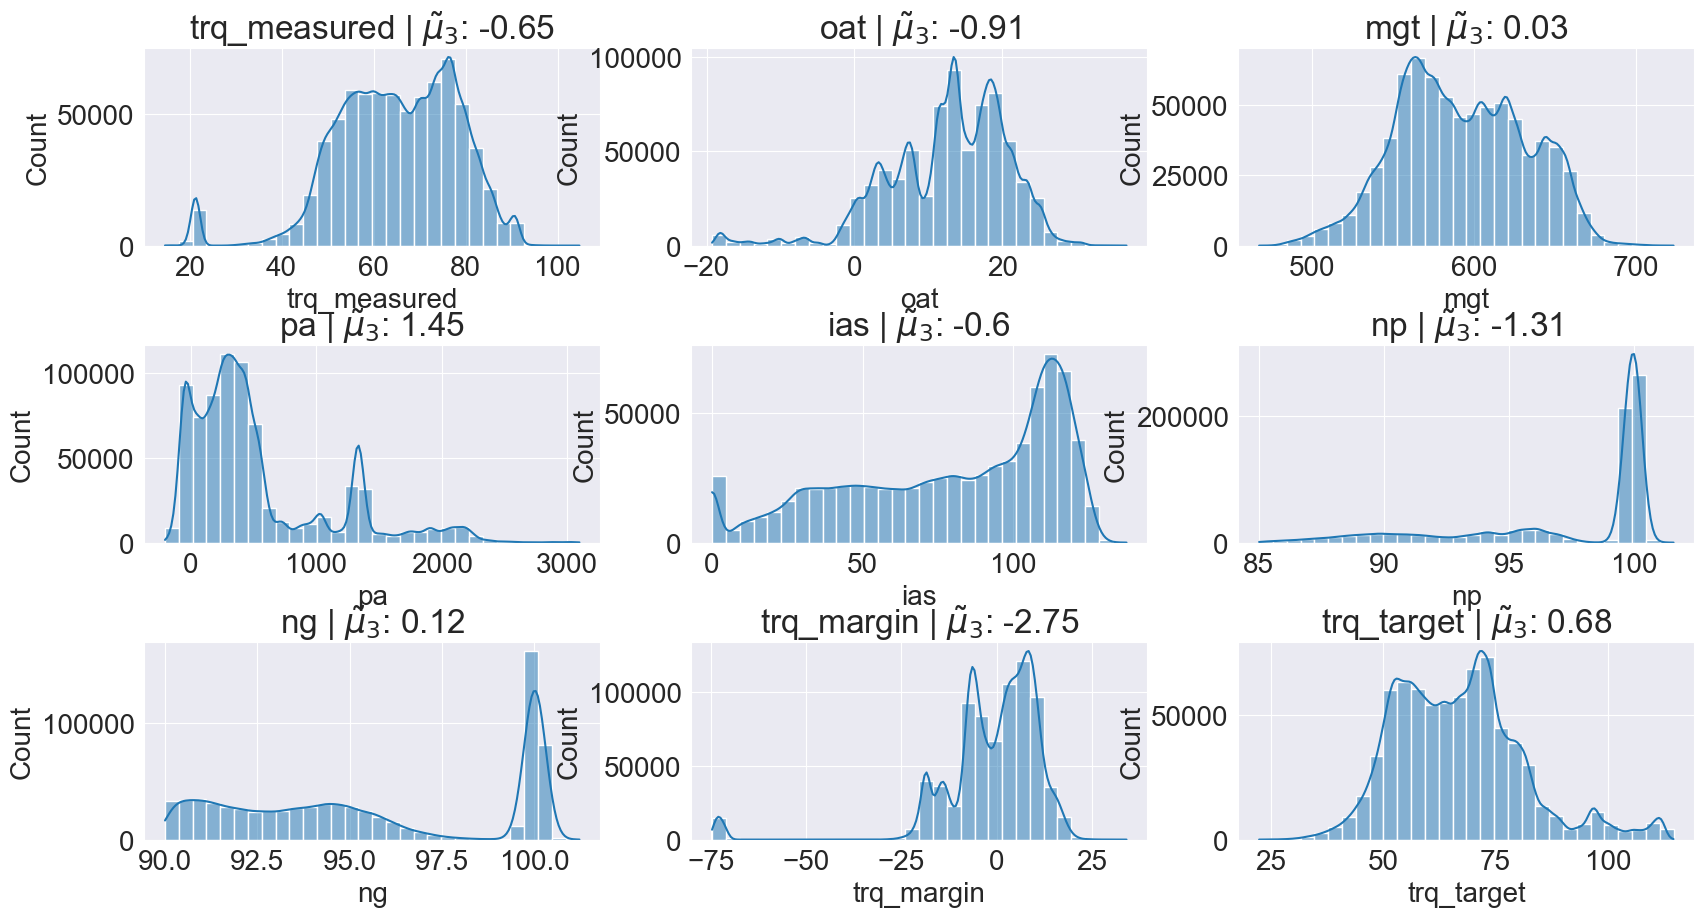

In [3]:
# 46s
columns = df_x.columns.to_list() + ['trq_margin', 'trq_target']
plt.figure(figsize=(20, len(columns) * 2))
for idx, feature in enumerate(columns, 1):
    plt.subplot((len(columns) + 1) // 2, 3, idx)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f"{feature} | " + "$\\tilde{\\mu}_3$" + f": {round(df[feature].skew(), 2)}")

plt.subplots_adjust(hspace=0.5)
plt.show()

### Faulty distributions

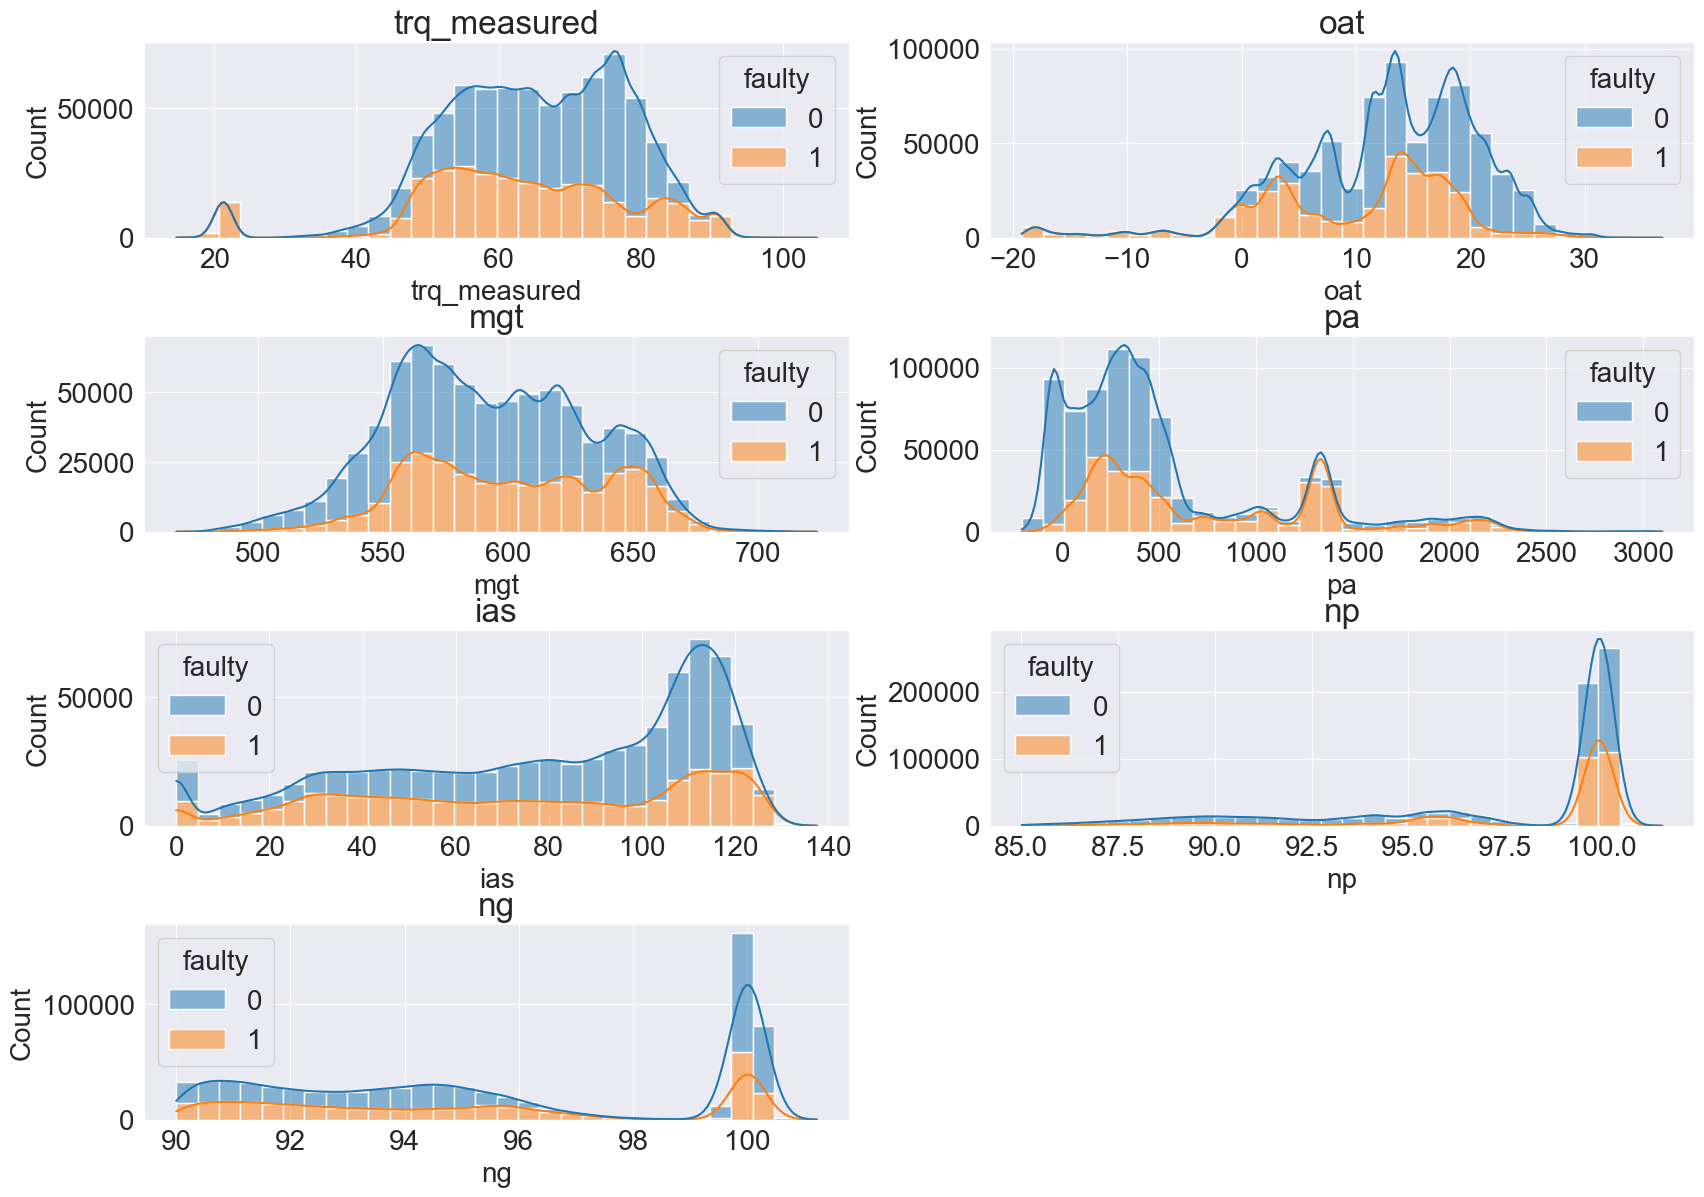

In [4]:
# 39s
plt.figure(figsize=(20, len(df_x.columns) * 2))
for idx, feature in enumerate(df_x.columns, 1):
    plt.subplot((len(df_x.columns) + 1) // 2, 2, idx)
    sns.histplot(data=df_x, x=feature, hue=df_y["faulty"], kde=True, bins=30, palette="tab10",
                 multiple="stack")
    plt.title(f"{feature}")
plt.subplots_adjust(hspace=0.5)
plt.show()

### Feature eptagram

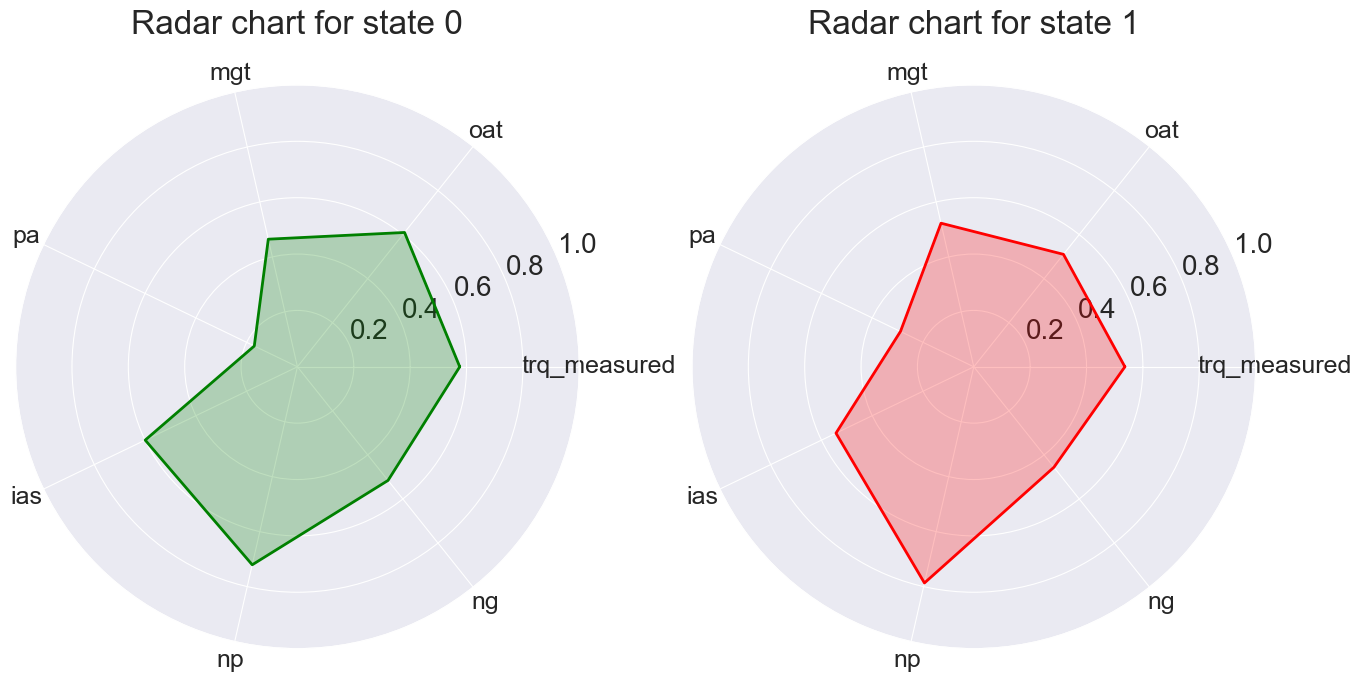

In [5]:
# 0s
fig, axs = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'polar': True})
for faulty in [0, 1]:
    features_means = df_normalized[df['faulty'] == faulty][df_x.columns].mean()
    features_means.loc[len(features_means)] = features_means.iloc[0]
    angles = np.linspace(0, 2 * np.pi, len(df_x.columns) + 1)

    axs[faulty].fill(angles, features_means, color=['g', 'r'][faulty], alpha=0.25)
    axs[faulty].plot(angles, features_means, color=['g', 'r'][faulty], linewidth=2)
    axs[faulty].set_xticks(angles[:-1])
    axs[faulty].set_xticklabels(df_x.columns, fontsize=18)
    axs[faulty].set_title(f'Radar chart for state {faulty}', pad=20)
    axs[faulty].set_ylim(0, 1)
plt.show()

### Correlation study

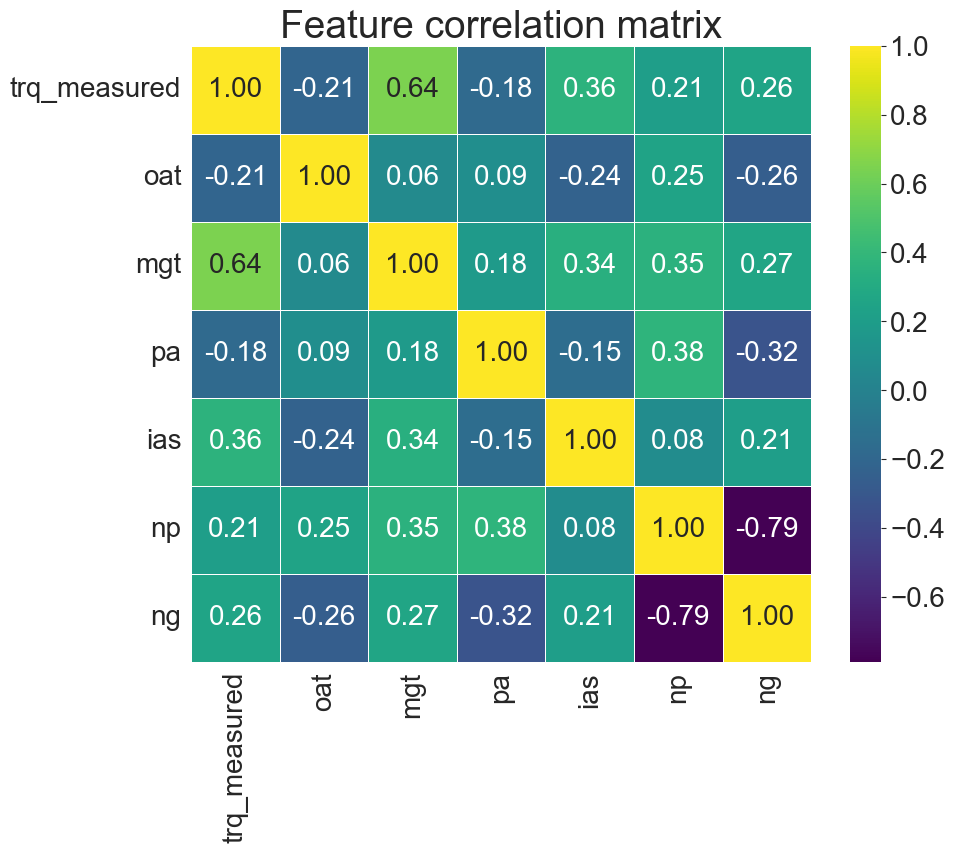

In [6]:
# 0s
plt.figure(figsize=(10, 8))
corr_matrix = df_x.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5, cbar=True)
plt.title("Feature correlation matrix", fontsize=28)
plt.show()

### PCA

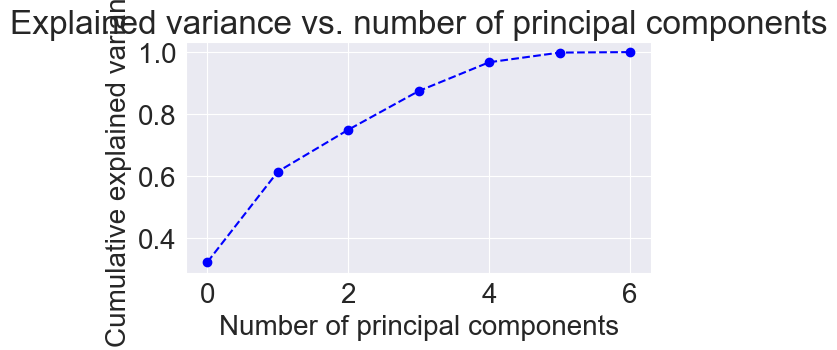

C:\Users\MrPio\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


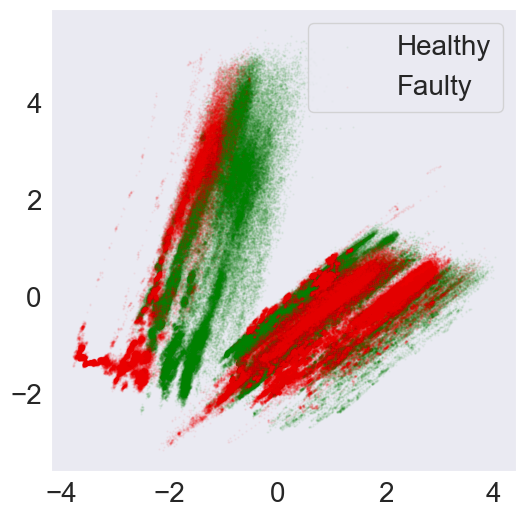

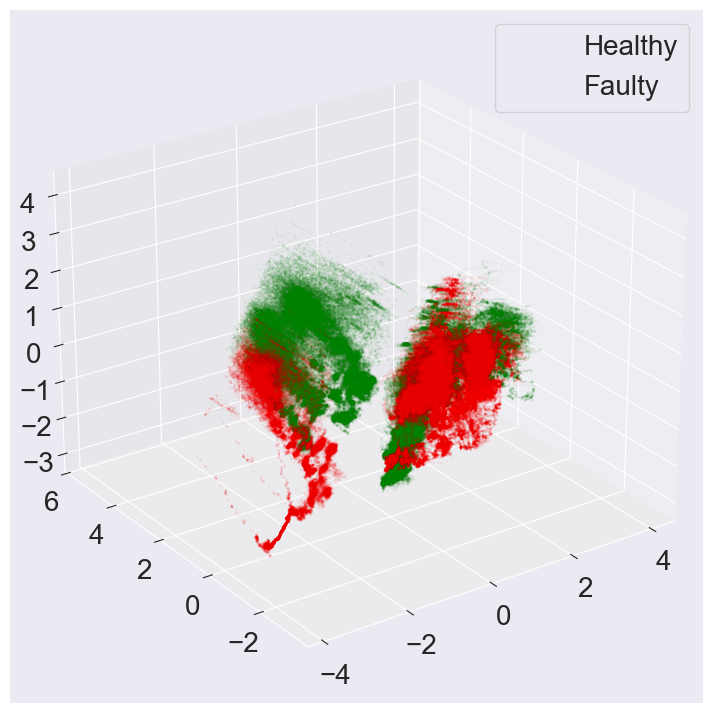

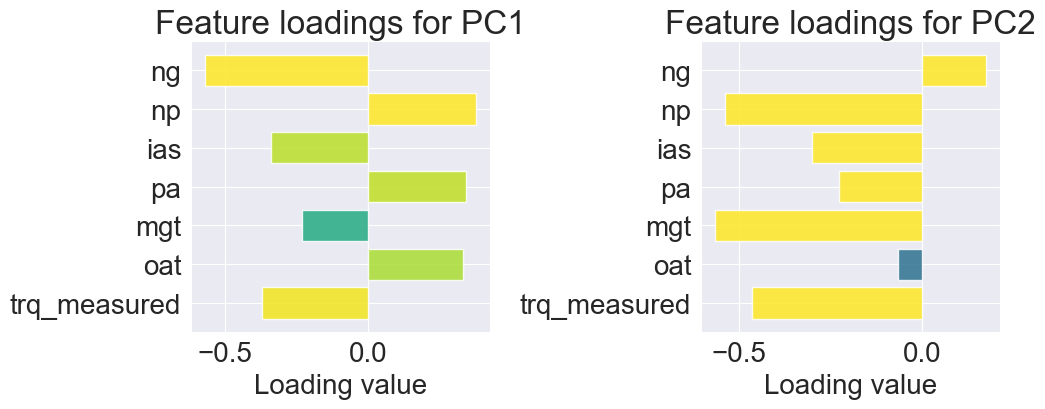

In [7]:
# 21s
pca = PCA(df_standardized[df_x.columns])
pca.plot_variance()
pca.plot_pca(labels=df_y['faulty']).legend()
pca.plot_pca(is_3d=True, labels=df_y['faulty'], scale=0.75).legend()
pca.plot_loadings(scale=0.75)

# Dataset sampling: skewness study
Here we ask whether a 10% subsample is representative of the population. Later training will use part of the dataset as the training set.

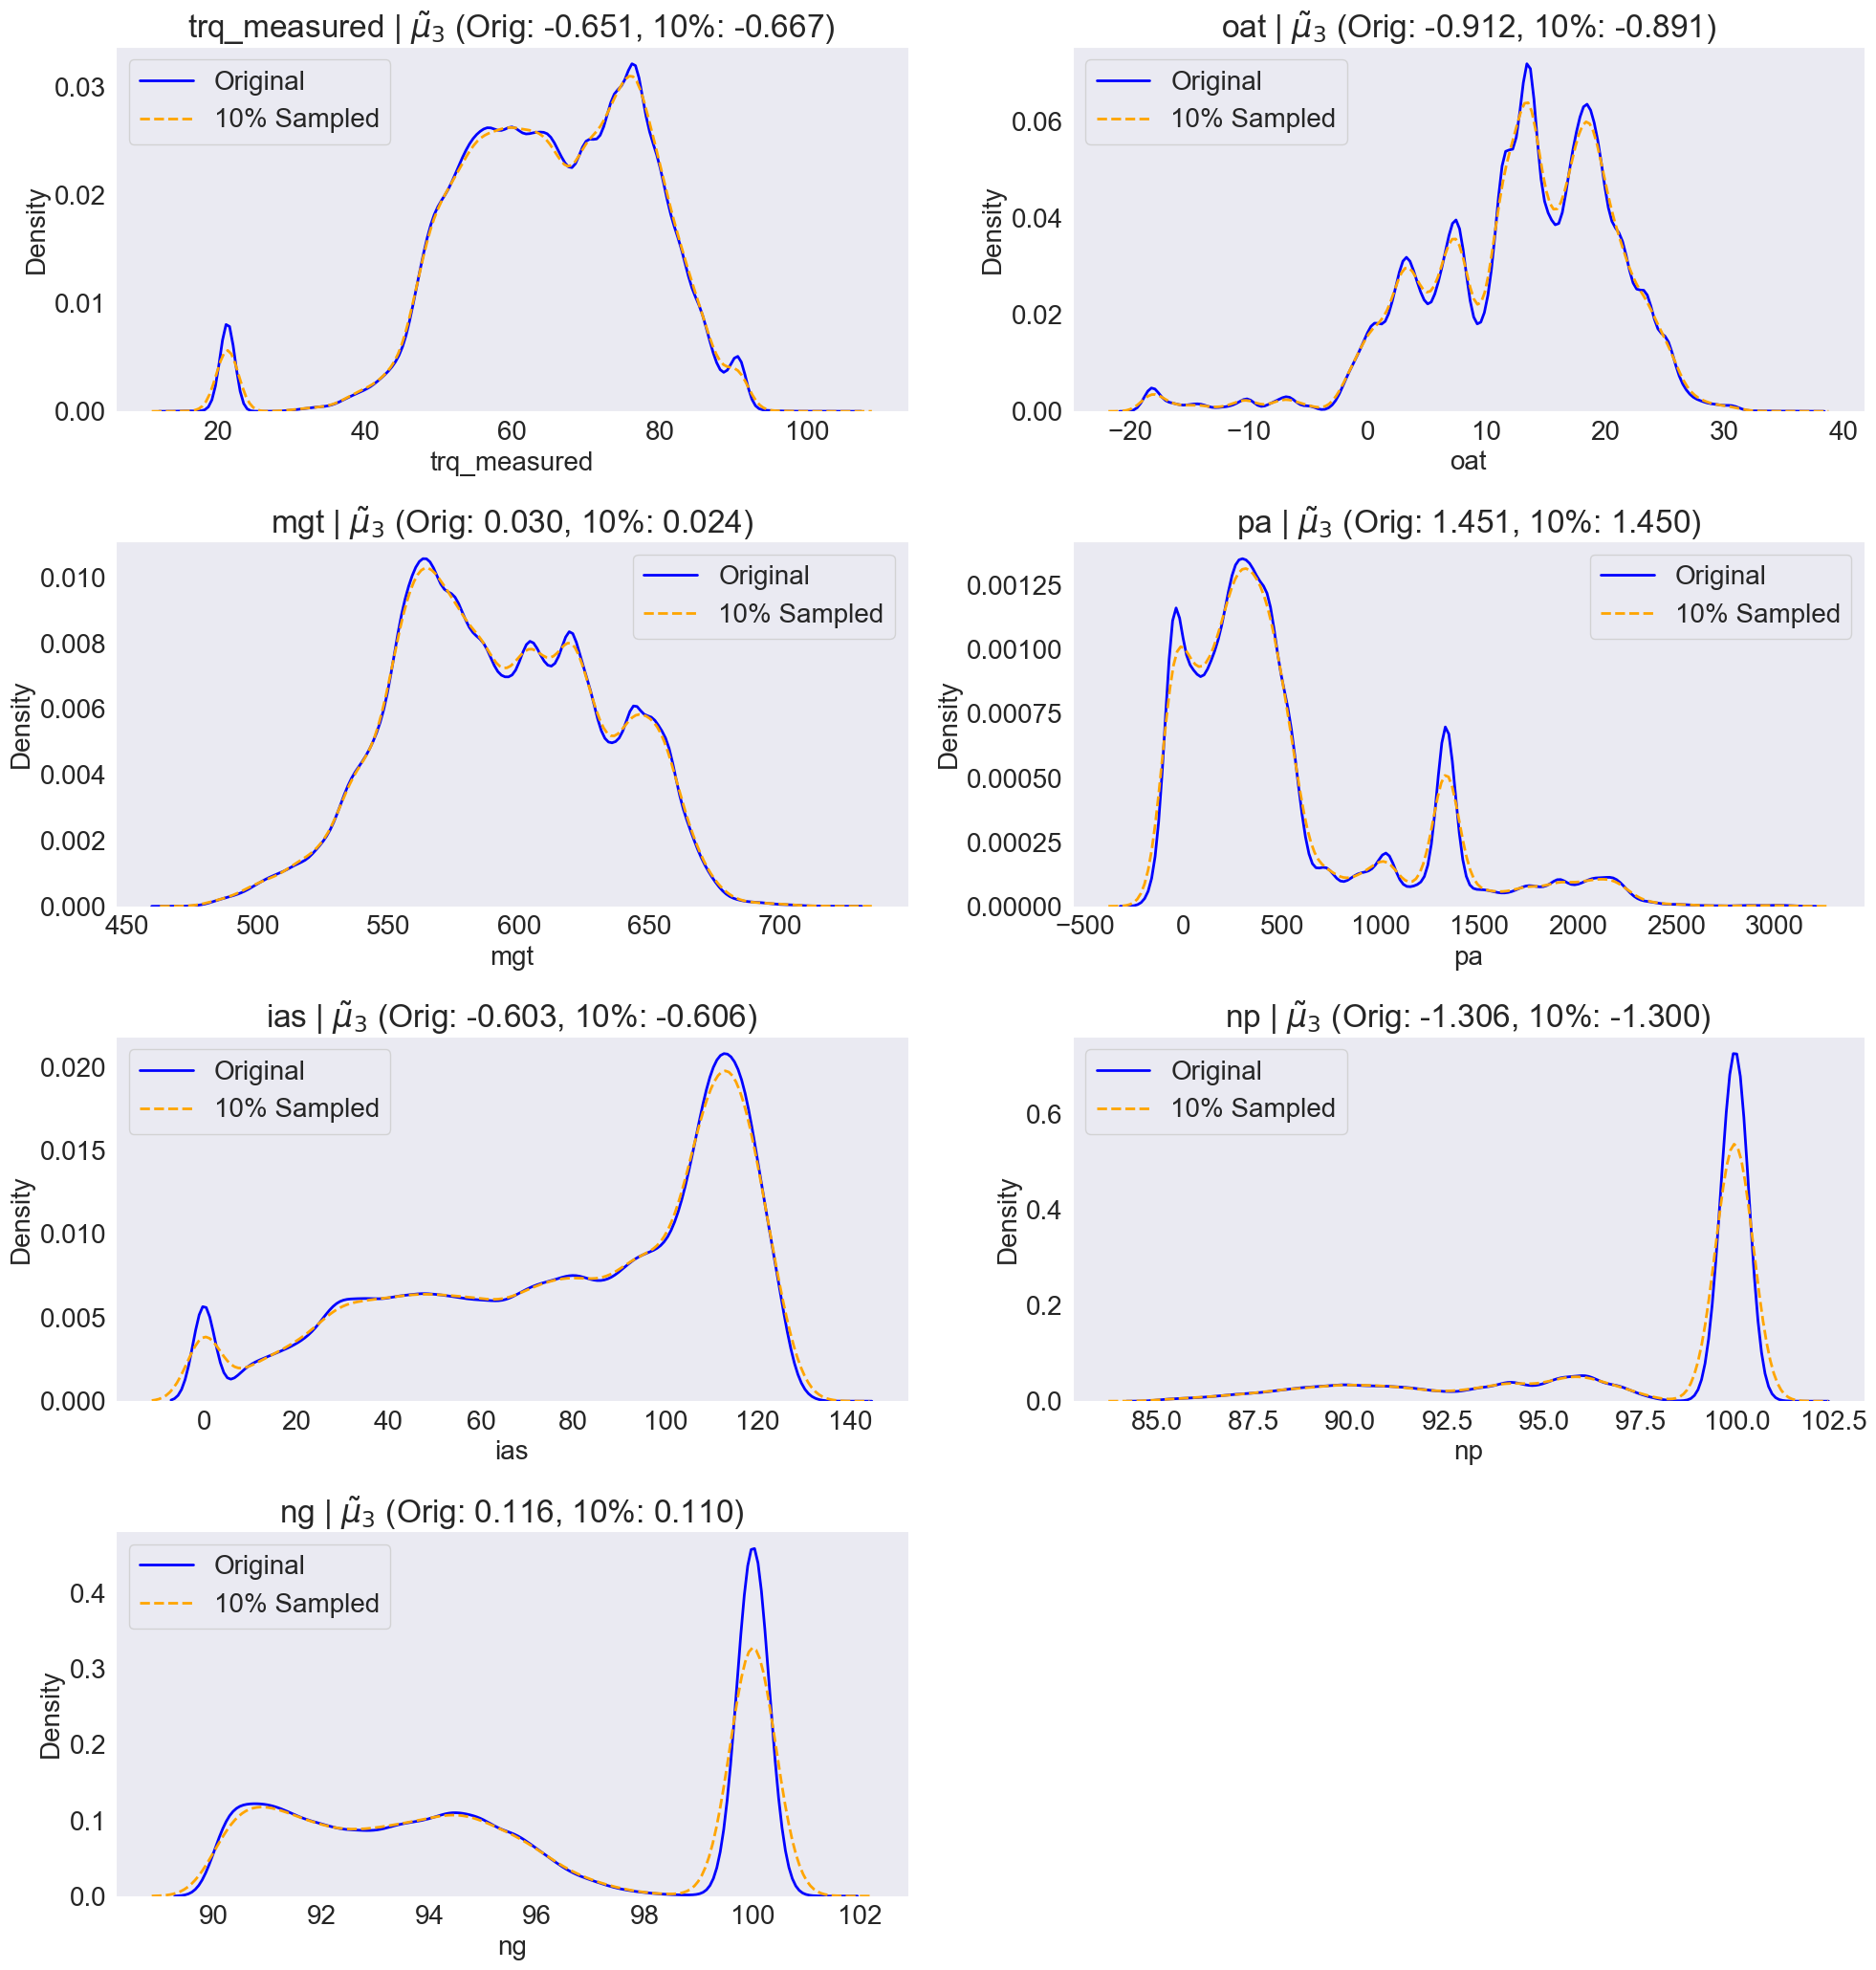

In [8]:
# 41s
random_indices = np.random.choice(len(df), size=len(df), replace=False)
df_10 = df.iloc[random_indices[:len(df) // 10]]

plt.figure(figsize=(20, len(df_x.columns) * 3))
for i, col in enumerate(df_x.columns):
    plt.subplot((len(df_x.columns) + 1) // 2, 2, i + 1)
    ax = sns.kdeplot(df[col], label="Original", color="blue", linewidth=2)
    sns.kdeplot(df_10[col], label="10% Sampled", color="orange", linestyle="dashed", linewidth=2, ax=ax)
    ax.set_title(
        f"{col} | " + "$\\tilde{\\mu}_3$" + f" (Orig: {df_x[col].skew():.3f}, 10%: {df_10[col].skew():.3f})")
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()